In [ ]:
!pip install tensorflow==2.15.0 tf-keras==2.15.0 scikit-learn matplotlib seaborn kaggle

import os

os.environ['KAGGLE_USERNAME'] = "DiyahSusan"
os.environ['KAGGLE_KEY'] = "KGAT_d80899ba67371285a9a5c22e87f47bb5"

!kaggle datasets download -d puneet6060/intel-image-classification
!unzip -q intel-image-classification.zip -d dataset/
print("Dataset berhasil didownload dan diekstrak!")

ERROR: Could not find a version that satisfies the requirement tensorflow==2.15.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.15.0
Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:19<00:00, 18.9MB/s]

Dataset berhasil didownload dan diekstrak!


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score

train_dir = 'dataset/seg_train/seg_train'
test_dir = 'dataset/seg_test/seg_test'

IMG_SIZE = (150, 150)
BATCH_SIZE = 32

print("Load Data Training:")
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int' # Label berupa angka 0-5
)

print("\nLoad Data Testing:")
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False # Jangan di-shuffle agar labelnya sejajar saat hitung F1-Score
)

# Ambil label asli dari data test untuk perhitungan F1-Score nanti
y_true = np.concatenate([y for x, y in test_ds], axis=0)
print(f"\nJumlah label test: {y_true.shape[0]}")

Load Data Training:
Found 14034 files belonging to 6 classes.

Load Data Testing:
Found 3000 files belonging to 6 classes.

Jumlah label test: 3000


In [3]:
def train_and_evaluate(model_name, model, epochs=10):
    print(f"\n" + "="*40)
    print(f" MULAI TRAINING: {model_name}")
    print("="*40)

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    # train model (validation langsung pakai test_ds)
    history = model.fit(train_ds, validation_data=test_ds, epochs=epochs)

    # hitung F1-Score
    print("\nMenghitung Macro F1-Score...")
    y_pred_probs = model.predict(test_ds)
    y_pred = np.argmax(y_pred_probs, axis=1)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    print(f"MACRO F1-SCORE: {macro_f1:.4f}")

    # simpan Bobot
    save_path = f"{model_name}.weights.h5"
    model.save_weights(save_path)
    print(f"Bobot disimpan di: {save_path}")

    # grafik loss & accuracy
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # accuracy
    axes[0].plot(history.history['accuracy'], label='Train Acc')
    axes[0].plot(history.history['val_accuracy'], label='Val Acc')
    axes[0].set_title(f'Accuracy - {model_name}')
    axes[0].legend()

    # loss
    axes[1].plot(history.history['loss'], label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title(f'Loss - {model_name}')
    axes[1].legend()

    plt.show()

    return history, macro_f1

# menyimpan skor akhir untuk perbandingan
hasil_eksperimen = {}

In [ ]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf
import tf_keras as keras

model_12_non_shared = keras.Sequential([
    keras.layers.InputLayer(input_shape=(150, 150, 3)),

    keras.layers.ZeroPadding2D(padding=(2, 2)),
    keras.layers.LocallyConnected2D(32, (5, 5), activation='relu'),
    keras.layers.AveragePooling2D(pool_size=(2, 2), strides=2),

    keras.layers.ZeroPadding2D(padding=(2, 2)),
    keras.layers.LocallyConnected2D(64, (5, 5), activation='relu'),
    keras.layers.AveragePooling2D(pool_size=(2, 2), strides=2),

    keras.layers.ZeroPadding2D(padding=(2, 2)),
    keras.layers.LocallyConnected2D(128, (5, 5), activation='relu'),
    keras.layers.AveragePooling2D(pool_size=(2, 2), strides=2),

    keras.layers.Flatten(),

    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(6, activation='softmax')
])

model_12_non_shared.summary()

_, f1_12_ns = train_and_evaluate("Non_Shared_Kombinasi_12", model_12_non_shared, epochs=10)
hasil_eksperimen["Non_Shared_Kombinasi_12"] = f1_12_ns

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 zero_padding2d_6 (ZeroPadd  (None, 154, 154, 3)       0         
 ing2D)                                                          
                                                                 
 locally_connected2d_6 (Loc  (None, 150, 150, 32)      54720000  
 allyConnected2D)                                                
                                                                 
 average_pooling2d_6 (Avera  (None, 75, 75, 32)        0         
 gePooling2D)                                                    
                                                                 
 zero_padding2d_7 (ZeroPadd  (None, 79, 79, 32)        0         
 ing2D)                                                          
                                                                 
 locally_connected2d_7 (Loc  (None, 75, 75, 64)       

In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf
import tf_keras as keras

model_12_non_shared = keras.Sequential([
    keras.layers.InputLayer(input_shape=(150, 150, 3)),

    keras.layers.AveragePooling2D(pool_size=(4, 4), strides=4),

    keras.layers.ZeroPadding2D(padding=(2, 2)),
    keras.layers.LocallyConnected2D(4, (3, 3), activation='relu'), # Filter 4
    keras.layers.AveragePooling2D(pool_size=(2, 2), strides=2),

    keras.layers.ZeroPadding2D(padding=(2, 2)),
    keras.layers.LocallyConnected2D(8, (3, 3), activation='relu'), # Filter 8
    keras.layers.AveragePooling2D(pool_size=(2, 2), strides=2),

    keras.layers.Flatten(),

    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(6, activation='softmax')
])

model_12_non_shared.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 average_pooling2d (Average  (None, 37, 37, 3)         0         
 Pooling2D)                                                      
                                                                 
 zero_padding2d (ZeroPaddin  (None, 41, 41, 3)         0         
 g2D)                                                            
                                                                 
 locally_connected2d (Local  (None, 39, 39, 4)         170352    
 lyConnected2D)                                                  
                                                                 
 average_pooling2d_1 (Avera  (None, 19, 19, 4)         0         
 gePooling2D)                                                    
                                                                 
 zero_padding2d_1 (ZeroPadd  (None, 23, 23, 4)         0


 MULAI TRAINING: Non_Shared_Kombinasi_12
Epoch 1/3
439/439 [==============================] - 102s 109ms/step - loss: 1.3443 - accuracy: 0.4773 - val_loss: 1.2011 - val_accuracy: 0.5397
Epoch 2/3
439/439 [==============================] - 27s 61ms/step - loss: 1.1083 - accuracy: 0.5714 - val_loss: 1.1030 - val_accuracy: 0.5770
Epoch 3/3
439/439 [==============================] - 27s 62ms/step - loss: 1.0148 - accuracy: 0.6151 - val_loss: 1.0221 - val_accuracy: 0.6153

Menghitung Macro F1-Score...
94/94 [==============================] - 23s 38ms/step
MACRO F1-SCORE: 0.6099
Bobot disimpan di: Non_Shared_Kombinasi_12.weights.h5


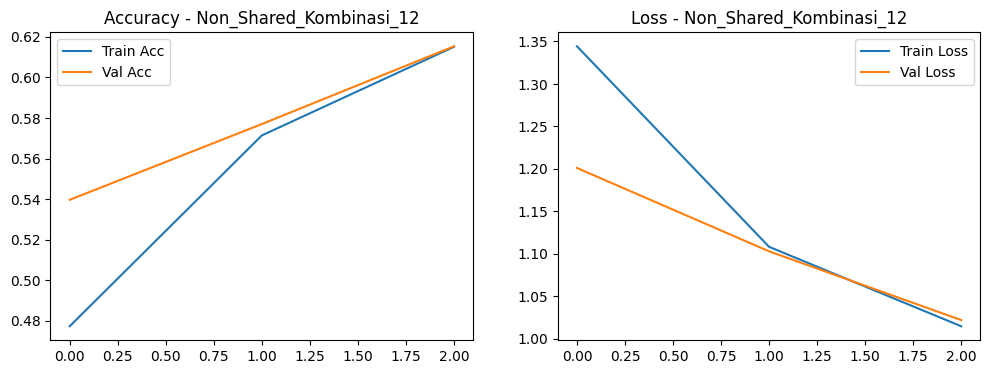

In [4]:
_, f1_12_ns = train_and_evaluate("Non_Shared_Kombinasi_12", model_12_non_shared, epochs=3)
hasil_eksperimen["Non_Shared_Kombinasi_12"] = f1_12_ns

In [5]:
model_12_shared = keras.Sequential([
    keras.layers.InputLayer(input_shape=(150, 150, 3)),

    keras.layers.AveragePooling2D(pool_size=(4, 4), strides=4),

    keras.layers.ZeroPadding2D(padding=(2, 2)),
    keras.layers.Conv2D(4, (3, 3), activation='relu'),
    keras.layers.AveragePooling2D(pool_size=(2, 2), strides=2),

    keras.layers.ZeroPadding2D(padding=(2, 2)),
    keras.layers.Conv2D(8, (3, 3), activation='relu'),
    keras.layers.AveragePooling2D(pool_size=(2, 2), strides=2),

    keras.layers.Flatten(),

    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(6, activation='softmax')
])

model_12_shared.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 average_pooling2d_3 (Avera  (None, 37, 37, 3)         0         
 gePooling2D)                                                    
                                                                 
 zero_padding2d_2 (ZeroPadd  (None, 41, 41, 3)         0         
 ing2D)                                                          
                                                                 
 conv2d (Conv2D)             (None, 39, 39, 4)         112       
                                                                 
 average_pooling2d_4 (Avera  (None, 19, 19, 4)         0         
 gePooling2D)                                                    
                                                                 
 zero_padding2d_3 (ZeroPadd  (None, 23, 23, 4)         0         
 ing2D)                                               


 MULAI TRAINING: Non_Shared_Kombinasi_12
Epoch 1/3
439/439 [==============================] - 80s 108ms/step - loss: 0.9550 - accuracy: 0.6394 - val_loss: 0.9673 - val_accuracy: 0.6257
Epoch 2/3
439/439 [==============================] - 30s 68ms/step - loss: 0.9046 - accuracy: 0.6599 - val_loss: 1.0526 - val_accuracy: 0.6060
Epoch 3/3
439/439 [==============================] - 29s 65ms/step - loss: 0.8615 - accuracy: 0.6765 - val_loss: 0.9512 - val_accuracy: 0.6480

Menghitung Macro F1-Score...
94/94 [==============================] - 24s 57ms/step
MACRO F1-SCORE: 0.6533
Bobot disimpan di: Non_Shared_Kombinasi_12.weights.h5


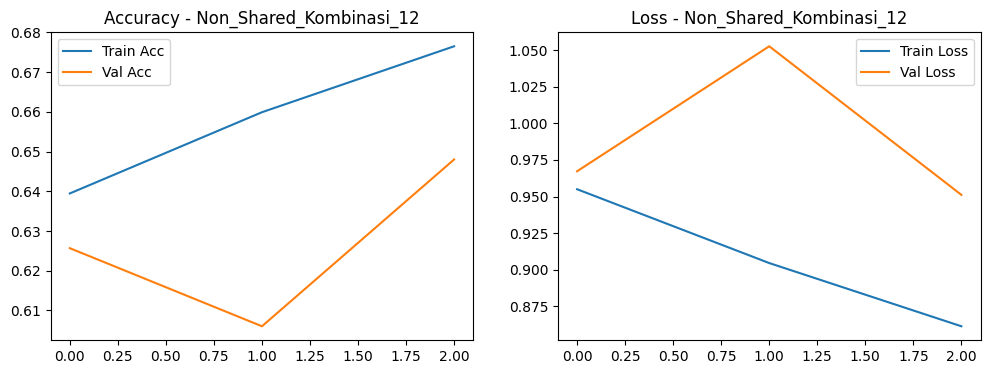

In [7]:
_, f1_12_s = train_and_evaluate("Non_Shared_Kombinasi_12", model_12_non_shared, epochs=3)
hasil_eksperimen["Shared_Kombinasi_12"] = f1_12_s

### Analisis
Pada eksperimen Shared VS Non-Shared, terjadi bottleneck yang menyebabkan proses training tidak mengalami progress sama sekali tetap saat menggunakan LocallyConnected dengan arsitektur kombinasi 12. Setelah di training selama satu jam, epoch 1 tidak menghasilkan progress apapun. Hal ini dikarenakan jumlah trainable parameternya sangat besar dan berukuran lebih dari 2GB. Oleh karena itu, agar tetap bisa membandingkan performa antara shared dan non-shared, maka dibuatlah arsitektur yang lebih sederhana dengan catatan perbandingan dilakukan *apple to apple* menggunakan arsitektur yang sama.

Berdasarkan hasil eksperimen, terlihat bahwa Macro F-1 score untuk shared parameter (0.6533) lebih tinggi dibandingkan untuk non-shared (0.6099) meskipun jumlah trainable parameternya jauh lebih sedikit. Hal ini membuktikan hipotesis bahwa performa non-shared parameter **sangat buruk** dan tidak efektif. Oleh karena itu, arsitektur non-shared parameter sudah sangat jarang digunakan dalam industri. Dengan arsitektur serupa namun menggunakan shared parameter terbukti menghasilkan nilai Macro F-1 score yang lebih baik dan proses training yang jauh lebih cepat.